<a href="https://colab.research.google.com/github/turryhit/data-analytics-public/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Analysis

# Load the data from BTS

In [1]:
query = """
SELECT
  `id`,
  `date`,
  `year`,
  `indicator`,
  `measure1`,
  `measure2`,
  `measure1_description`,
  `measure2_description`,
  `value1`,
  `units`,
  `note`,
  `source`
LIMIT 50000
  """

In [2]:
from urllib.parse import quote

URL = f"https://data.bts.gov/resource/y5ut-ibwt.json?$query={quote(query)}"

In [3]:
import pandas as pd
df = pd.read_json(URL)

# Cleaning the data

In [4]:
# Let's see what indicators are in the data
df["indicator"].unique()

array(['Capacity of Containerships Calling at U.S. Ports (in TEUs)',
       'Empty Export Containers (in TEUs), Aggregated Select U.S. Ports',
       'Containerized Exports at U.S. Ports in TEUs',
       'Containerized Imports at U.S. Ports in TEUs',
       'U.S. Class I Total Rail Non-Intermodal Carloads',
       'U.S. Class I Rail Intermodal Units',
       'U.S. Class I Containers on Rail Flat Cars',
       'U.S. Class I Trailers on a Rail Flat Car',
       'Freight Transportation Services Index',
       'Average Truck Speed in MPH at 10 Bottleneck Locations',
       'Average Planning Time Index at 10 Bottleneck Locations',
       'Average Truck Speed in MPH Around Port of Los Angeles-Long Beach',
       'Average Truck Speed in MPH Around Port of New York-New Jersey',
       'PTI Around Port of Los Angeles-Long Beach',
       'PTI Around Port of New York-New Jersey',
       'Number of Non-Farm Truck Transportation Employees \xa0in Thousands (Seasonally Adjusted)',
       'Number of W

In [5]:
# We want to look at imports and exports at specific ports
import_df = df[df["indicator"] == "Loaded Import Containers at Select U.S. Ports in TEUs"]
export_df = df[df["indicator"] == "Loaded Export Containers at Select U.S. Ports in TEUs"]

In [6]:
# Let's rename the generic measure1 column to port
import_df = import_df.rename(columns={"measure1": "port", "value1": "import_teus"})
export_df = export_df.rename(columns={"measure1": "port", "value1": "export_teus"})

In [7]:
# Let's only keep the columns we are interested in
import_df = import_df[["date", "import_teus", "port"]]
export_df = export_df[["date", "export_teus", "port"]]

In [8]:
# Let's set an index
import_df = import_df.set_index(["date", "port"])
export_df = export_df.set_index(["date", "port"])

In [9]:
# Since we've used two columns as the index, we now have a MultiIndex
# We can refer to a row by using the following syntax:
import_df.loc[("2019-01-01", "Houston")]

,2019-01-01
,Houston
import_teus,95318.0


In [10]:
# Let's join our two dataframes together to have import/export information on one row

ie_df = import_df.join(export_df)

In [11]:
# Let's reset the index to have a column port (and no longer a multi-index)
ie_df = ie_df.reset_index(level=1)

In [12]:
ie_df.index = pd.to_datetime(ie_df.index, utc=True)

# Plotting the data

In [13]:
import seaborn as sns

<Axes: xlabel='date', ylabel='import_teus'>

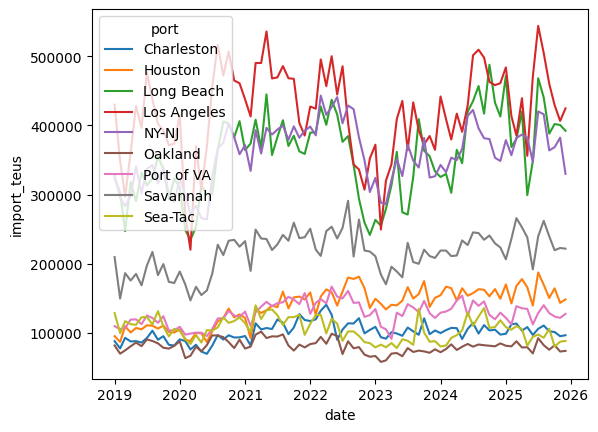

In [14]:
sns.lineplot(ie_df, x=ie_df.index, y="import_teus", hue="port")

<Axes: xlabel='import_teus', ylabel='export_teus'>

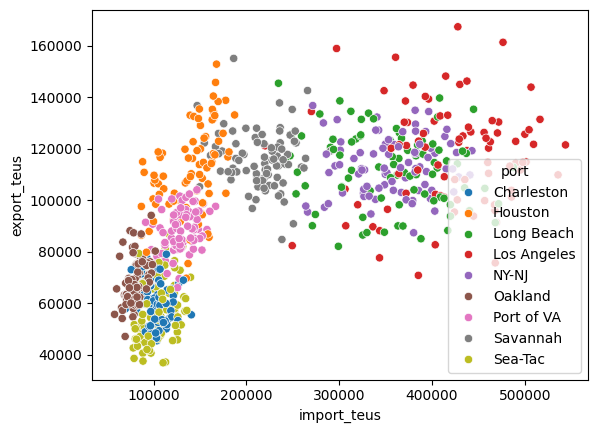

In [15]:
sns.scatterplot(ie_df, x="import_teus", y="export_teus", hue="port")

# Linear Regression

In [16]:
# Let's download statsmodels
!pip install statsmodels

In [17]:
import statsmodels.api as sm
import numpy as np

# Let's run an OLS regression to determine the relationship between exports and imports

y = ie_df['export_teus'].to_numpy()
X = sm.add_constant(ie_df['import_teus'].to_numpy())
model = sm.OLS(y, X).fit()

X_predict = np.array([1, 100_000])  # The 1 here is the constant, needed for the regression model, ignore IT!
predictions = model.predict(X_predict)
predictions

array([77905.25726171])

In [18]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     602.0
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           3.50e-98
Time:                        09:46:44   Log-Likelihood:                -8573.7
No. Observations:                 756   AIC:                         1.715e+04
Df Residuals:                     754   BIC:                         1.716e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.379e+04   1424.350     44.787      0.000     6.1e+04    6.66e+04
x1             0.1411      0.006     24.536      0.000       0.130       0.152
==============================================================================
Omnibus:                       18.187   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.676
Skew:                           0.366   Prob(JB):                     8.80e-05
Kurtosis:                       2.760   Cond. No.                     4.75e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.75e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='export_teus', ylabel='import_teus'>

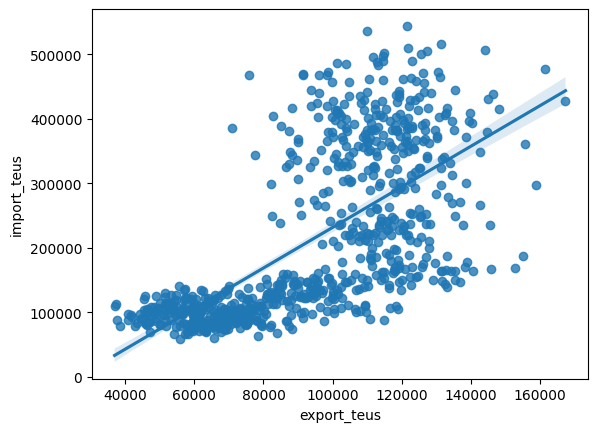

In [19]:
# We can view our prediction line
sns.regplot(ie_df, x=ie_df["export_teus"], y=ie_df["import_teus"])

In [20]:
# We can now use our prediction line to make predictions
import numpy as np
X_predict = np.array([1, 100_000])  # The 1 here is the constant, needed for the regression model, ignore IT!
predictions = model.predict(X_predict)
predictions

array([77905.25726171])

# Let's analyse the relationship between the different ports

In [21]:
ie_df

,port,import_teus,export_teus
date,,,
2019-01-01 00:00:00+00:00,Charleston,88107.00,63750.0
2019-01-01 00:00:00+00:00,Houston,95318.00,87961.0
2019-01-01 00:00:00+00:00,Long Beach,323838.00,131436.0
2019-01-01 00:00:00+00:00,Los Angeles,429922.75,144993.0
2019-01-01 00:00:00+00:00,NY-NJ,327345.00,111833.0
...,...,...,...
2025-12-01 00:00:00+00:00,NY-NJ,329914.00,105438.0
2025-12-01 00:00:00+00:00,Oakland,74031.00,66019.0
2025-12-01 00:00:00+00:00,Port of VA,127602.00,85160.0


In [22]:
ports = ie_df["port"].unique()

In [23]:
rsquares = []
for port in ports:
  port_rsquares = []
  for port_2 in ports:
    y = ie_df[ie_df["port"] == port]['import_teus']
    X = sm.add_constant(ie_df[ie_df["port"] == port_2]['import_teus'])
    model = sm.OLS(y, X).fit()

    port_rsquares.append(model.rsquared)
  rsquares.append(port_rsquares)

In [24]:
r_df = pd.DataFrame(rsquares, index=ports, columns=ports)

In [25]:
r_df

,Charleston,Houston,Long Beach,Los Angeles,NY-NJ,Oakland,Port of VA,Savannah,Sea-Tac
Charleston,1.000000,0.514789,0.169899,0.113094,0.531774,0.063904,0.533555,0.521923,0.025379
Houston,0.514789,1.000000,0.205720,0.073336,0.455710,0.000240,0.460286,0.532589,0.018257
Long Beach,0.169899,0.205720,1.000000,0.595660,0.526882,0.260749,0.242773,0.368747,0.224663
Los Angeles,0.113094,0.073336,0.595660,1.000000,0.422282,0.425585,0.219221,0.294581,0.255383
NY-NJ,0.531774,0.455710,0.526882,0.422282,1.000000,0.253258,0.648988,0.696164,0.119173
Oakland,0.063904,0.000240,0.260749,0.425585,0.253258,1.000000,0.112899,0.148875,0.421293
Port of VA,0.533555,0.460286,0.242773,0.219221,0.648988,0.112899,1.000000,0.599093,0.059980
Savannah,0.521923,0.532589,0.368747,0.294581,0.696164,0.148875,0.599093,1.000000,0.057119
Sea-Tac,0.025379,0.018257,0.224663,0.255383,0.119173,0.421293,0.059980,0.057119,1.000000


<Axes: >

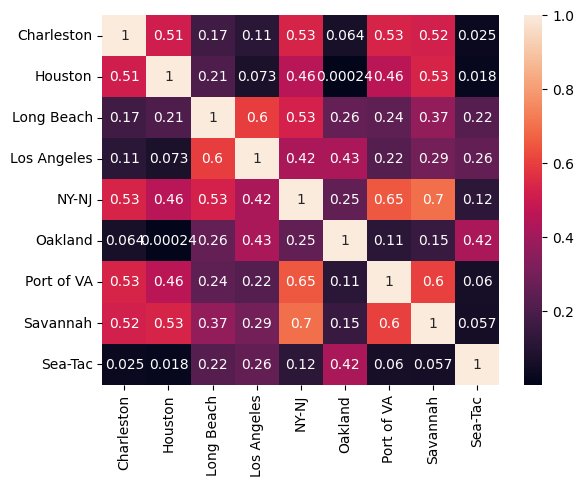

In [26]:
sns.heatmap(r_df, annot=True)